In [1]:
# ⚠️ Installation nécessaire
!pip install autofeat

In [2]:
import pandas as pd
import numpy as np
from autofeat import AutoFeatClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import lightgbm as lgb
import os
from sklearn.utils import check_array
import autofeat.autofeat

# 🚑 MONKEY PATCH : CORRECTION BUG SKLEARN/AUTOFEAT
# AutoFeat utilise un vieil argument 'force_all_finite' renommé 'ensure_all_finite' dans les scikit-learn récents.

def check_array_patched(*args, **kwargs):
    if 'force_all_finite' in kwargs:
        kwargs['ensure_all_finite'] = kwargs.pop('force_all_finite')
    return check_array(*args, **kwargs)

autofeat.autofeat.check_array = check_array_patched
print("🚑 Patch AutoFeat appliqué (compatible Sklearn récent).")
print("✅ Bibliothèques importées.")
import matplotlib.pyplot as plt

def nuclear_type_fix(df, df_name='DF'):
    print(f'☢️ Nuclear Type Fix on {df_name}...')
    # 1. Force known numeric cols
    force_cols = ['age', 'new_user', 'total_pages_visited']
    for c in force_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce').astype('float32')
            print(f'   -> Forced {c} to float32')
    # 2. Check remaining objects
    for c in df.select_dtypes(include='object').columns:
        # Try to convert to numeric
        num_c = pd.to_numeric(df[c], errors='coerce')
        # If we have a significant number of valid numeric conversions (>50%), assume it's numeric
        if num_c.notna().mean() > 0.5:
             df[c] = num_c.astype('float32')
             print(f'   -> Auto-converted object col {c} to float32')
        else:
             # It is likely categorical. LightGBM handles category dtype best.
             df[c] = df[c].astype('category')
             print(f'   -> Converted categorical col {c} to category')
    print(f'✅ {df_name} dtypes fixed.')



🚑 Patch AutoFeat appliqué (compatible Sklearn récent).
✅ Bibliothèques importées.


In [3]:
# 1. CHARGEMENT DES DONNÉES
print("⏳ Chargement des données...")
try:
    train_df = pd.read_csv('conversion_data_train.csv')
    test_df = pd.read_csv('conversion_data_test.csv')
    print(f"✅ Données chargées. Train: {train_df.shape}, Test: {test_df.shape}")
except FileNotFoundError:
    print("❌ Erreur : Fichiers CSV introuvables. Vérifiez le chemin.")

⏳ Chargement des données...
✅ Données chargées. Train: (284580, 6), Test: (31620, 5)


In [4]:
# 2. PRÉPARATION BASIQUE
X = train_df.drop('converted', axis=1)
y = train_df['converted']
X_test = test_df

# FIX: Force numeric types
cols_to_fix = ['age', 'new_user', 'total_pages_visited']
for col in cols_to_fix:
    X[col] = pd.to_numeric(X[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

print("✅ Enforced numeric types for:", cols_to_fix)

✅ Enforced numeric types for: ['age', 'new_user', 'total_pages_visited']


In [5]:
# 3. CONFIGURATION AUTOFEAT ULTRA-OPTIMISÉE (MODE TURBO)
# Basé sur les recommandations : on réduit la voilure pour garantir que ça termine.

# Echantillon très réduit pour la découverte (5000 lignes suffisent pour trouver les patterns)
SAMPLE_SIZE = min(5000, len(X))
print(f"🔬 Découverte des features sur un échantillon de {SAMPLE_SIZE} lignes...")

X_sample = X.sample(n=SAMPLE_SIZE, random_state=42)
y_sample = y.loc[X_sample.index]

model_af = AutoFeatClassifier(
    categorical_cols=['country', 'source'],
    feateng_steps=1,         # 🔴 STOP à 1 étape. (2 étapes = exponentiel et trop long)
    verbose=1,               # On veut voir ce qui se passe
    n_jobs=1                 # 🔴 1 seul CPU pour éviter l'overhead multiprocessing qui bloque tout
)

# Phase 1 : FIT sur le SAMPLE
print("🦾 Phase 1 : Apprentissage des transformations (FIT) sur l'échantillon...")
model_af.fit(X_sample, y_sample)
print(f"✅ Features trouvées ({len(model_af.new_feat_cols_)}) :", model_af.new_feat_cols_)

# Phase 2 : TRANSFORM sur TOUT le dataset
# Avec n_jobs=1, cela peut prendre un peu de temps mais on est sûr que ça avance.
print("⚡ Phase 2 : Application des transformations (TRANSFORM) sur tout le Train set...")
X_af = model_af.transform(X)

# APPLY NUCLEAR FIX
nuclear_type_fix(X_af, 'X_af')


print(f"✅ Terminé ! Nouvelle shape : {X_af.shape}")

2025-12-16 10:23:42,931 WARNING: [AutoFeat] This just calls fit_transform() but does not return the transformed dataframe.
2025-12-16 10:23:42,932 INFO: [AutoFeat] It is much more efficient to call fit_transform() instead of fit() and transform()!
2025-12-16 10:23:42,938 INFO: [AutoFeat] The 1 step feature engineering process could generate up to 70 features.
2025-12-16 10:23:42,938 INFO: [AutoFeat] With 5000 data points this new feature matrix would use about 0.00 gb of space.
2025-12-16 10:23:42,939 INFO: [feateng] Step 1: transformation of original features


🔬 Découverte des features sur un échantillon de 5000 lignes...
🦾 Phase 1 : Apprentissage des transformations (FIT) sur l'échantillon...


2025-12-16 10:23:44,025 INFO: [feateng] Generated 10 transformed features from 10 original features - done.
2025-12-16 10:23:44,026 INFO: [feateng] Generated altogether 10 new features in 1 steps
2025-12-16 10:23:44,027 INFO: [feateng] Removing correlated features, as well as additions at the highest level
2025-12-16 10:23:44,033 INFO: [feateng] Generated a total of 5 additional features
2025-12-16 10:23:44,038 INFO: [featsel] Feature selection run 1/5


[featsel] Scaling data...done.


2025-12-16 10:23:48,551 INFO: [featsel] Feature selection run 2/5
2025-12-16 10:23:53,576 INFO: [featsel] Feature selection run 3/5
2025-12-16 10:23:58,134 INFO: [featsel] Feature selection run 4/5
2025-12-16 10:24:02,796 INFO: [featsel] Feature selection run 5/5
2025-12-16 10:24:06,910 INFO: [featsel] 2 features after 5 feature selection runs
/home/phil/.gemini/antigravity/scratch/venv/lib/python3.12/site-packages/autofeat/featsel.py:270: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  if np.max(np.abs(correlations[c].ravel()[:i])) < 0.9:
2025-12-16 10:24:06,912 INFO: [featsel] 2 features after correlation filtering
2025-12-16 10:24:07,532 INFO: [featsel] 2 features after noise filtering
2025-12-16 10:24:07,532 INFO: [AutoFeat] Computing 1 new features.
2025-12-16 10:24:07,639 INFO: [AutoFeat]     1/    1 new features ...done.
2025-12-16 10:24:07,641 INFO: [AutoFeat] 

2025-12-16 10:24:07,867 INFO: [AutoFeat] Trained model: largest coefficients:
2025-12-16 10:24:07,868 INFO: [-3.39573047]
2025-12-16 10:24:07,869 INFO: 0.026360 * total_pages_visited
2025-12-16 10:24:07,870 INFO: 0.003468 * total_pages_visited**3
2025-12-16 10:24:07,874 INFO: [AutoFeat] Final score: 0.9442
2025-12-16 10:24:08,029 INFO: [AutoFeat] Computing 1 new features.
2025-12-16 10:24:08,054 INFO: [AutoFeat]     1/    1 new features ...done.


✅ Features trouvées (1) : ['total_pages_visited**3']
⚡ Phase 2 : Application des transformations (TRANSFORM) sur tout le Train set...
☢️ Nuclear Type Fix on X_af...tures
   -> Forced age to float32
   -> Forced new_user to float32
   -> Forced total_pages_visited to float32
✅ X_af dtypes fixed.
✅ Terminé ! Nouvelle shape : (284580, 11)


In [6]:
# 4. SAUVEGARDE INTERMÉDIAIRE (CRITIQUE)
print("💾 Sauvegarde des features intermédiaires...")
X_af.to_csv('train_autofeat_features.csv', index=False)

# Transformation du test set
print("🦾 Transformation du Test Set...")
X_test_af = model_af.transform(X_test)

# APPLY NUCLEAR FIX
nuclear_type_fix(X_test_af, 'X_test_af')
X_test_af.to_csv('test_autofeat_features.csv', index=False)
print("✅ Features sauvegardées dans 'train_autofeat_features.csv' et 'test_autofeat_features.csv'")

💾 Sauvegarde des features intermédiaires...


2025-12-16 10:24:08,727 INFO: [AutoFeat] Computing 1 new features.
2025-12-16 10:24:08,731 INFO: [AutoFeat]     1/    1 new features ...done.


🦾 Transformation du Test Set...
☢️ Nuclear Type Fix on X_test_af...
   -> Forced age to float32
   -> Forced new_user to float32
   -> Forced total_pages_visited to float32
✅ X_test_af dtypes fixed.
✅ Features sauvegardées dans 'train_autofeat_features.csv' et 'test_autofeat_features.csv'


🚀 Entraînement LightGBM sur les nouvelles features...
☢️ Nuclear Type Fix on X_af_before_train...
   -> Forced age to float32
   -> Forced new_user to float32
   -> Forced total_pages_visited to float32
✅ X_af_before_train dtypes fixed.
Training until validation scores don't improve for 50 rounds
[100]	train's binary_logloss: 0.0395098	train's auc: 0.987438	valid's binary_logloss: 0.0416373	valid's auc: 0.985367
Early stopping, best iteration is:
[134]	train's binary_logloss: 0.0389485	train's auc: 0.988241	valid's binary_logloss: 0.0415796	valid's auc: 0.985337
Keys in evals_result: odict_keys(['binary_logloss', 'auc'])


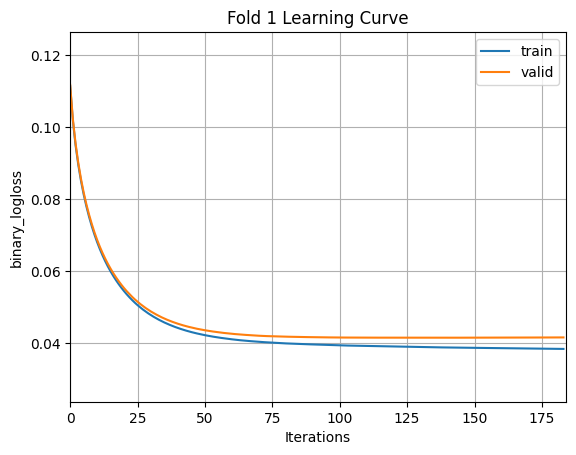

Training until validation scores don't improve for 50 rounds
[100]	train's binary_logloss: 0.0394591	train's auc: 0.987609	valid's binary_logloss: 0.0412934	valid's auc: 0.985495
Early stopping, best iteration is:
[76]	train's binary_logloss: 0.0402141	train's auc: 0.986508	valid's binary_logloss: 0.0415913	valid's auc: 0.98562
Keys in evals_result: odict_keys(['binary_logloss', 'auc'])


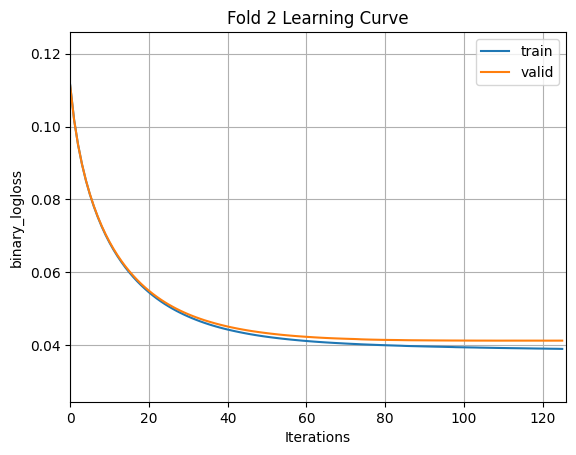

Training until validation scores don't improve for 50 rounds
[100]	train's binary_logloss: 0.0394103	train's auc: 0.987664	valid's binary_logloss: 0.0415946	valid's auc: 0.986028
Early stopping, best iteration is:
[128]	train's binary_logloss: 0.0389561	train's auc: 0.988182	valid's binary_logloss: 0.0414713	valid's auc: 0.986139
Keys in evals_result: odict_keys(['binary_logloss', 'auc'])


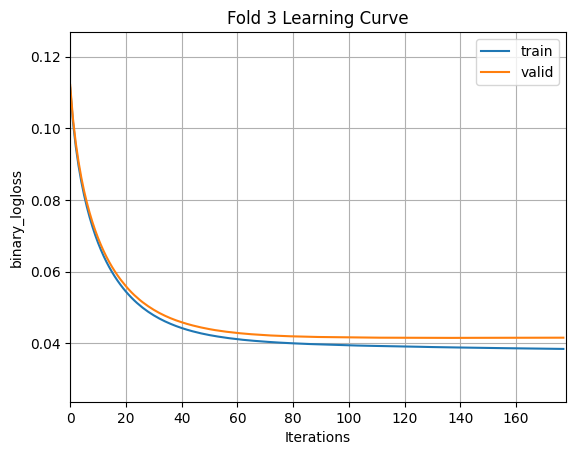

Training until validation scores don't improve for 50 rounds
[100]	train's binary_logloss: 0.0394778	train's auc: 0.987958	valid's binary_logloss: 0.0413939	valid's auc: 0.983785
Early stopping, best iteration is:
[93]	train's binary_logloss: 0.0396427	train's auc: 0.987762	valid's binary_logloss: 0.041453	valid's auc: 0.98392
Keys in evals_result: odict_keys(['binary_logloss', 'auc'])


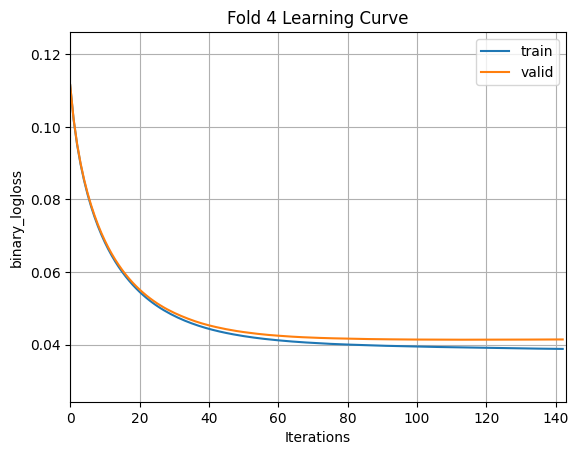

Training until validation scores don't improve for 50 rounds
[100]	train's binary_logloss: 0.0399943	train's auc: 0.987276	valid's binary_logloss: 0.0394615	valid's auc: 0.987288
Early stopping, best iteration is:
[97]	train's binary_logloss: 0.040055	train's auc: 0.987218	valid's binary_logloss: 0.0394902	valid's auc: 0.987309
Keys in evals_result: odict_keys(['binary_logloss', 'auc'])


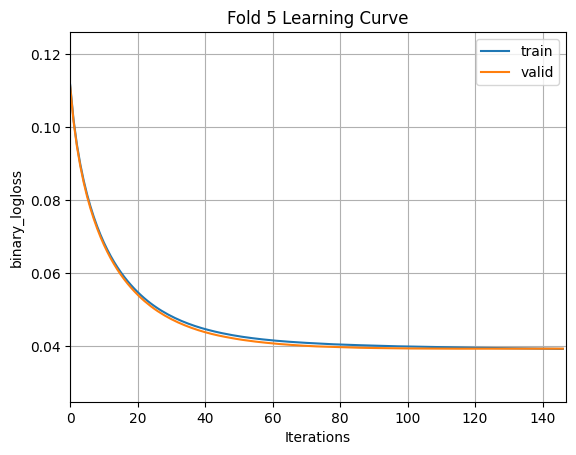


🏆 Score F1 CV (Autofeat + LightGBM) : 0.76761 au seuil 0.41


In [7]:
# 5. ENTRAÎNEMENT MODÈLE FINAL
print("🚀 Entraînement LightGBM sur les nouvelles features...")

# FINAL SAFETY CHECK
nuclear_type_fix(X_af, 'X_af_before_train')



lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_probas_cv = np.zeros(len(X_af))

for fold_i, (train_idx, val_idx) in enumerate(cv.split(X_af, y)):
    X_train_fold, X_val_fold = X_af.iloc[train_idx], X_af.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
    
    # Store results for plotting
    evals_result = {}
    
    lgb_model.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_train_fold, y_train_fold), (X_val_fold, y_val_fold)],
        eval_names=['train', 'valid'],
        eval_metric=['binary_logloss', 'auc'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(100),
            lgb.record_evaluation(evals_result)
        ]
    )
    
    # Plot learning curve
    print('Keys in evals_result:', evals_result['train'].keys())
    lgb.plot_metric(evals_result, metric='binary_logloss')
    plt.title(f'Fold {fold_i+1} Learning Curve')
    plt.show()
    y_probas_cv[val_idx] = lgb_model.predict_proba(X_val_fold)[:, 1]

thresholds = np.arange(0.3, 0.7, 0.01)
best_f1 = 0
best_thresh = 0.5

for t in thresholds:
    score = f1_score(y, (y_probas_cv > t).astype(int))
    if score > best_f1:
        best_f1 = score
        best_thresh = t

print(f"\n🏆 Score F1 CV (Autofeat + LightGBM) : {best_f1:.5f} au seuil {best_thresh:.2f}")


📊 Analyse des Features Importantes...


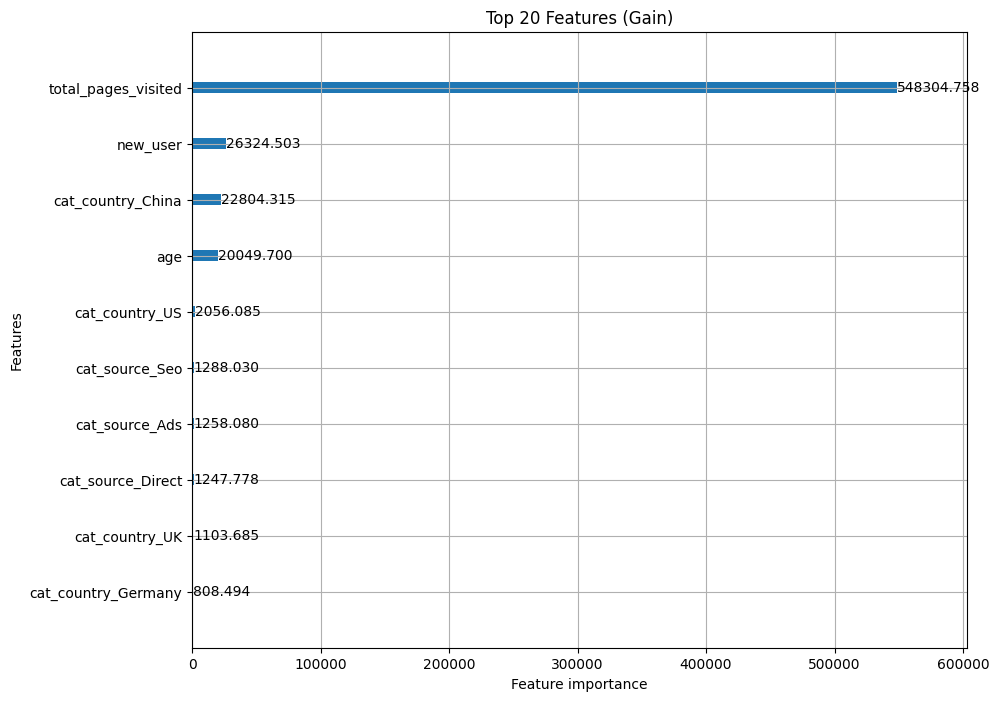

🔝 Top 10 Features et Combinaisons :
               Feature  Importance
0                  age       10064
2  total_pages_visited        9970
1             new_user        2611
9       cat_source_Seo        1343
6       cat_country_US        1171
7       cat_source_Ads        1138
8    cat_source_Direct        1111
5       cat_country_UK        1063
3    cat_country_China         826
4  cat_country_Germany         703
✅ Rapport sauvegardé : feature_importance_report.csv
🎉 Fichier de soumission généré : submission_AUTOFEAT_FULL.csv

🏆 MEILLEUR SCORE F1 CROSS-VALIDATION : 0.76761
🎯 SEUIL OPTIMAL APPLIQUÉ : 0.41


In [8]:
# 6. GÉNÉRATION SOUMISSION
lgb_model.fit(X_af, y)

# --- FEATURE IMPORTANCE ANALYSIS ---
print("\n📊 Analyse des Features Importantes...")
lgb.plot_importance(lgb_model, max_num_features=20, importance_type='gain', figsize=(10, 8), title='Top 20 Features (Gain)')
plt.show()

# Récapitulatif texte
feature_imp = pd.DataFrame({
    'Feature': X_af.columns,
    'Importance': lgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("🔝 Top 10 Features et Combinaisons :");
print(feature_imp.head(10))

# Sauvegarde
feature_imp.to_csv('feature_importance_report.csv', index=False)
print("✅ Rapport sauvegardé : feature_importance_report.csv")

test_probas = lgb_model.predict_proba(X_test_af)[:, 1]
test_preds = (test_probas > best_thresh).astype(int)

filename = 'submission_AUTOFEAT_FULL.csv'
sub = pd.DataFrame({'converted': test_preds})
sub.to_csv(filename, index=False)
print(f"🎉 Fichier de soumission généré : {filename}")

# --- RAPPEL SCORE FINAL ---
print("\n" + "="*40)
print(f"🏆 MEILLEUR SCORE F1 CROSS-VALIDATION : {best_f1:.5f}")
print(f"🎯 SEUIL OPTIMAL APPLIQUÉ : {best_thresh:.2f}")
print("="*40)
